### Sequential graoh

In [1]:
from typing import  TypedDict, List
from langgraph.graph import StateGraph, START, END

In [4]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    result: int


In [16]:
def adder(state: AgentState) -> AgentState:
     
     """
     The method adds up two numbers.
     """

     state['result'] = state['number1'] +  state['number2'] 

     return state

def substructer(state: AgentState) -> AgentState:
     
     """
     The method substructs up two numbers.
     """

     state['result'] = state['number1'] -  state['number2'] 

     return state

def decision_node(state: AgentState) -> AgentState:
     
     """
     The method makes selection on next phase of the graph.  
     """

     if  state['operation']  == '+':
          return "add_operation"   
     elif state['operation']  == '-':
          return "substruct_operation"   


In [26]:
graph = StateGraph(AgentState)

graph.add_node('add_node', adder)
graph.add_node('substruct_node', substructer)
graph.add_node('router', lambda state: state)

graph.add_edge(START, 'router')
graph.add_conditional_edges(
    'router',
    decision_node, 
    {
        "add_operation": "add_node",
        "substruct_operation": "substruct_node",
    }
)

graph.add_edge('add_node', END)
graph.add_edge('substruct_node', END)

app = graph.compile()

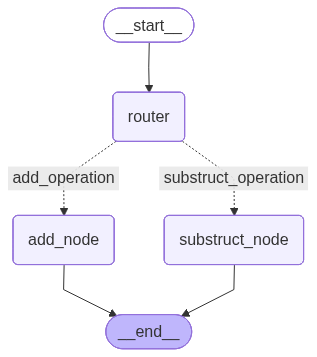

In [27]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
init_state = AgentState(number1= 1, number2= 2, operation='+')
print(app.invoke(init_state))

{'number1': 1, 'number2': 2, 'operation': '+', 'result': 3}
